<a href="https://colab.research.google.com/github/Anuska111/E-Commerce-Customer-Lifetime-Value-CLV-Segmentation/blob/main/E_Commerce_Customer_Lifetime_Value_(CLV)_%26_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Import Required Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
##Load Dataset
df = pd.read_csv("/content/online_retail_II.csv.zip")

In [ ]:
##Dataset Check
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [ ]:
#Data Cleaning
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(26479)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [ ]:
#Feature Engineering (RFM)
snapshot_date = df["InvoiceDate"].max()

In [ ]:
rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Revenue": "sum",
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days
}).reset_index()

In [ ]:
rfm.columns = [
    "CustomerID",
    "Frequency",
    "Monetary",
    "Recency"
]

In [ ]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

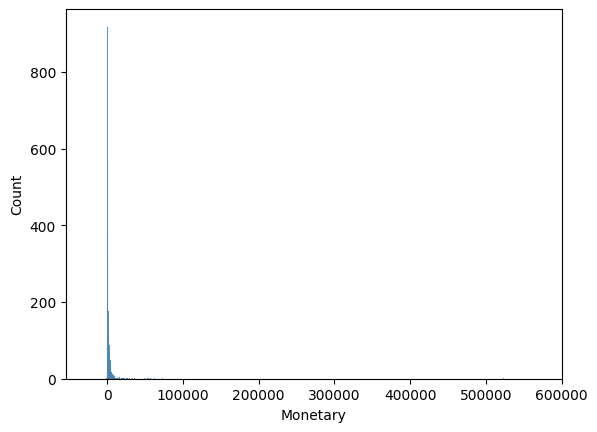

In [ ]:
#Revenue Distribution
sns.histplot(rfm["Monetary"])

plt.show()

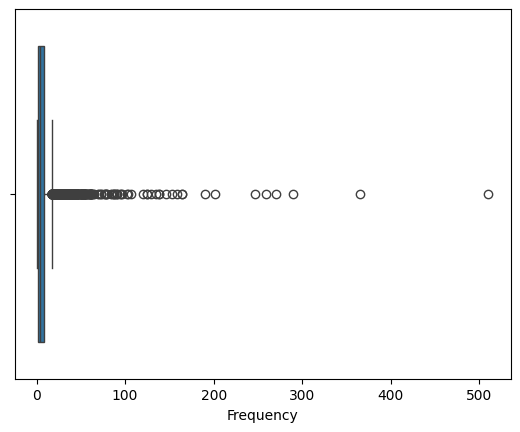

In [ ]:
#Frequency Distribution
sns.boxplot(x=rfm["Frequency"])

plt.show()

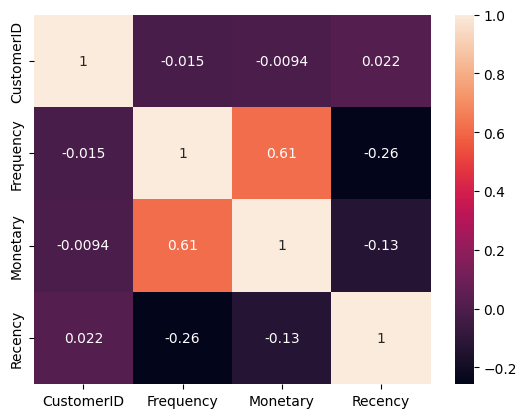

In [ ]:
#Correlation
sns.heatmap(rfm.corr(), annot=True)

plt.show()

In [ ]:
#Data Scaling
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(

rfm[['Recency','Frequency','Monetary']]
)

In [ ]:
#Customer Segmentation
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)
rfm["Cluster"] = kmeans.fit_predict(
scaled_data
)

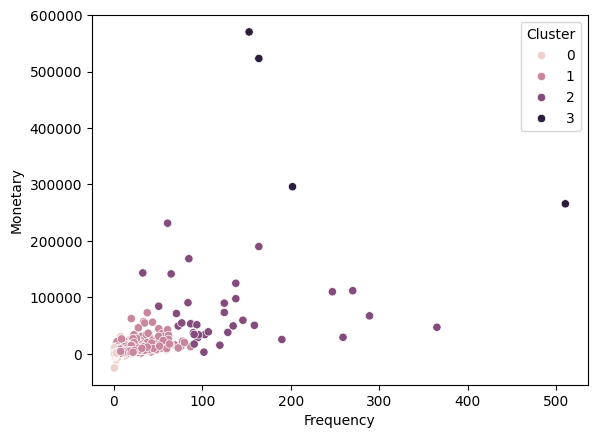

In [ ]:
sns.scatterplot(
data=rfm,
x="Frequency",
y="Monetary",
hue="Cluster"
)
plt.show()

In [ ]:
#Evaluate Clustering
from sklearn.metrics import silhouette_score

In [ ]:
score = silhouette_score(
scaled_data,
rfm["Cluster"]
)
print(score)

0.5909076847358011


In [ ]:
#Create CLV
rfm["CLV"] = (
rfm["Frequency"]
*
rfm["Monetary"]
)

In [ ]:
#Train Regression Model
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

In [ ]:
X = rfm[
["Recency","Frequency","Monetary"]
]
y = rfm["CLV"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
test_size=0.2,
random_state=42
)

In [ ]:
model = RandomForestRegressor(
random_state=42)
model.fit(
X_train,
y_train
)

RandomForestRegressor(random_state=42)

In [ ]:
#Evaluate Model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [ ]:
prediction = model.predict(
X_test
)

In [ ]:
#RMSE
rmse = np.sqrt(
mean_squared_error(
y_test,
prediction))

In [ ]:
#R² Score
r2 = r2_score(
y_test,
prediction
)

In [ ]:
#MAPE
mape = np.mean(
np.abs(
(y_test-prediction)/y_test))*100

In [ ]:
#Predict New Customer
new_customer = pd.DataFrame({
"Recency":[10],
"Frequency":[15],
"Monetary":[25000]})
model.predict(new_customer)

array([290702.6861])

In [ ]:
#Dashboard
!pip install streamlit
import streamlit as st
st.set_page_config(page_title="CLV Dashboard", layout="wide")
st.title("🛒 E-Commerce Customer Lifetime Value Dashboard")
st.header("Business Summary")
st.header("Customer Segmentation")
st.header("Revenue Analysis")
st.header("Predict Customer Lifetime Value")

2026-07-24 18:35:48.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 18:35:48.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()